In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
from src.ft_engineering import feature_engineering

In [2]:
df = pd.read_excel("../data/raw/Base_de_datos.xlsx")

df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [3]:
X_train, X_test, y_train, y_test = feature_engineering(df)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8610, 62)
Test shape: (2153, 62)


# 1. Funciones reutilizables

In [4]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

def build_model(model, X_train, y_train):
    model.fit(X_train, y_train)
    return model


def summarize_classification(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print("Accuracy:", accuracy)
    print("ROC AUC:", roc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return accuracy, roc

# 2. Definir modelos

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 3. Entrenar y evaluar

In [6]:
results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    trained_model = build_model(model, X_train, y_train)
    accuracy, roc = summarize_classification(trained_model, X_test, y_test)
    results[name] = {"Accuracy": accuracy, "ROC AUC": roc}


===== Logistic Regression =====
Accuracy: 0.9526242452392011
ROC AUC: 0.661767095916865

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       102
           1       0.95      1.00      0.98      2051

    accuracy                           0.95      2153
   macro avg       0.48      0.50      0.49      2153
weighted avg       0.91      0.95      0.93      2153


===== Random Forest =====


/Users/felipebaquero/Desktop/Data Science/DS1/ml-versionamiento-eda/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/felipebaquero/Desktop/Data Science/DS1/ml-versionamiento-eda/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/felipebaquero/Desktop/Data Science/DS1/ml-versionamiento-eda/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

Accuracy: 0.9526242452392011
ROC AUC: 0.6500009560138048

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       102
           1       0.95      1.00      0.98      2051

    accuracy                           0.95      2153
   macro avg       0.48      0.50      0.49      2153
weighted avg       0.91      0.95      0.93      2153


===== Gradient Boosting =====


/Users/felipebaquero/Desktop/Data Science/DS1/ml-versionamiento-eda/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/felipebaquero/Desktop/Data Science/DS1/ml-versionamiento-eda/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/felipebaquero/Desktop/Data Science/DS1/ml-versionamiento-eda/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

Accuracy: 0.9507663725034835
ROC AUC: 0.6853041557920097

Classification Report:

              precision    recall  f1-score   support

           0       0.17      0.01      0.02       102
           1       0.95      1.00      0.97      2051

    accuracy                           0.95      2153
   macro avg       0.56      0.50      0.50      2153
weighted avg       0.92      0.95      0.93      2153



# 4. Tabla resumen

Tras eliminar variables con posible fuga de información, el desempeño del modelo disminuyó significativamente, evidenciando que el puntaje crediticio explicaba casi completamente la variable objetivo.
El mejor modelo resultó ser Gradient Boosting con un ROC AUC de 0.685, lo que indica una capacidad predictiva moderada.
La alta precisión observada (~0.95) se debe principalmente al desbalance del dataset, donde la clase mayoritaria representa el 95% de los casos.

In [ ]:
#En base a esto se determina quitar en ft_engineering.py puntaje y puntaje_datacredito.
df.corr(numeric_only=True)["Pago_atiempo"].sort_values(ascending=False)

Pago_atiempo                     1.000000
puntaje                          0.923134
puntaje_datacredito              0.067882
promedio_ingresos_datacredito    0.039867
edad_cliente                     0.032252
creditos_sectorFinanciero        0.021390
creditos_sectorCooperativo       0.021267
saldo_total                      0.014364
saldo_principal                  0.011473
cant_creditosvigentes            0.008829
saldo_mora_codeudor              0.002631
tipo_credito                     0.000951
salario_cliente                 -0.003981
total_otros_prestamos           -0.010041
cuota_pactada                   -0.011814
creditos_sectorReal             -0.023306
capital_prestado                -0.040624
plazo_meses                     -0.063105
saldo_mora                      -0.073458
huella_consulta                 -0.073737
Name: Pago_atiempo, dtype: float64

In [7]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df.sort_values(by="ROC AUC", ascending=False)

,Accuracy,ROC AUC
Gradient Boosting,0.950766,0.685304
Logistic Regression,0.952624,0.661767
Random Forest,0.952624,0.650001


# 5. Gráfico comparativo

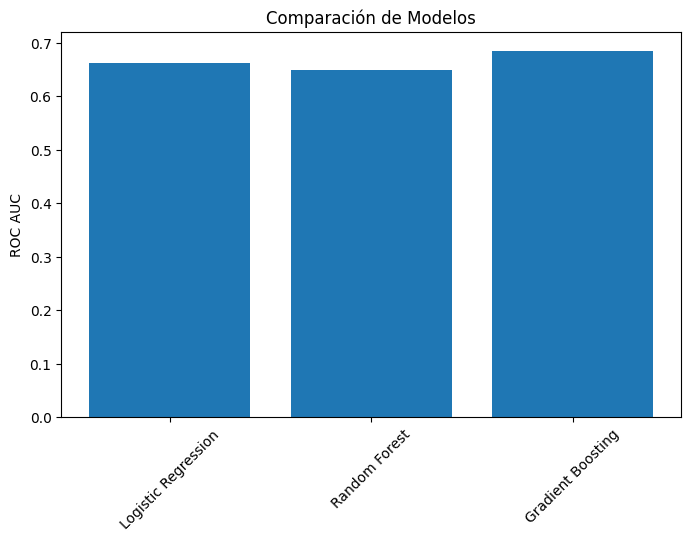

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df.index, results_df["ROC AUC"])
plt.ylabel("ROC AUC")
plt.title("Comparación de Modelos")
plt.xticks(rotation=45)
plt.show()